# Garbage Image Classification — CNN with TensorFlow

## Overview
This notebook builds and evaluates a convolutional neural network (CNN) to classify images of garbage into four material categories: brown glass, green glass, white glass, and plastic.

The objective was to improve on a provided baseline CNN model (validation F1: 0.873) by applying regularisation and enhanced data augmentation techniques.

**Final Result:** Validation F1 score of 0.913 (saved best model weights)

## Dataset
Images sourced from the [Garbage Classification dataset on Kaggle](https://www.kaggle.com/datasets/mostafaabla/garbage-classification) by Mostafa Abla.

## Approach
1. Data preparation and preprocessing (resizing, normalisation, class balancing)
2. Data augmentation (rotation, zoom, flipping, shear)
3. CNN architecture with batch normalisation and L2 regularisation
4. Training with early stopping, learning rate reduction, and model checkpointing
5. Evaluation via F1 score, confusion matrix, and per-class classification report

## Environment
Built and trained in Google Colab using a GPU (L4) runtime.

In [ ]:
# Run this only in Google Colab
!pip install tensorflow matplotlib numpy scikit-learn kaggle

In [ ]:
# Core Libraries
import os
import re
import shutil
import random
import zipfile
from collections import defaultdict

# Numerical/Scientific
import numpy as np
import pandas as pd

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Activation, Dropout,
    GlobalAveragePooling2D, Dense, Input
)
from tensorflow.keras.preprocessing.image import (
    load_img, img_to_array, save_img, ImageDataGenerator
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

# Using google colab to work with imported files -- in this case, kaggle
try:
  from google.colab import files
except ImportError:
  pass # Not running in Colab

In [ ]:
tf.__version__

'2.18.0'

##Downloading Data via Kaggle

In [ ]:
files.upload() # Upload kaggle.json (API token) to Colab - Only run in Colab

source = r"/content/kaggle.json"
destination = os.path.expanduser('~/.kaggle/kaggle.json')

os.makedirs(os.path.dirname(destination), exist_ok=True)
shutil.copy(source, destination)

Saving kaggle.json to kaggle.json


'/root/.kaggle/kaggle.json'

In [ ]:
!kaggle datasets download -d mostafaabla/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
 94% 225M/239M [00:01<00:00, 259MB/s]
100% 239M/239M [00:01<00:00, 224MB/s]


In [ ]:
# Unzip the file
with zipfile.ZipFile('/content/garbage-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
DIR_PATH = os.path.abspath("garbage_classification/")
folders_to_keep = os.listdir(DIR_PATH)
folders_to_keep

['clothes',
 'paper',
 'plastic',
 'battery',
 'cardboard',
 'brown-glass',
 'shoes',
 'biological',
 'green-glass',
 'white-glass',
 'metal',
 'trash']

In [ ]:
# Get a list of folders to keep
folders_to_keep = [folder for folder in folders_to_keep if ('glass' in folder or 'plastic' in folder) ]
folders_to_keep

['plastic', 'brown-glass', 'green-glass', 'white-glass']

In [ ]:
os.listdir(DIR_PATH) # View the current directory

['clothes',
 'paper',
 'plastic',
 'battery',
 'cardboard',
 'brown-glass',
 'shoes',
 'biological',
 'green-glass',
 'white-glass',
 'metal',
 'trash']

## Removing unnecessary data

In [ ]:
for folder in os.listdir(DIR_PATH):
  if folder not in folders_to_keep:
    shutil.rmtree(os.path.join(DIR_PATH, folder)) # Delete all folders not relevant to this project
os.listdir(DIR_PATH) # View the new directory

['plastic', 'brown-glass', 'green-glass', 'white-glass']

##Data Preparation & Pre-processing

In [ ]:
TARGET_HEIGHT = 128
TARGET_WIDTH = 128

def preprocess_img_to_arr(img, target_height = TARGET_HEIGHT, target_width = TARGET_WIDTH):
    img_arr = np.asarray(img)
    img_tensor = tf.convert_to_tensor(img_arr)
    return img_tensor

In [ ]:
# store preprocessed images in new folder
NEW_DIR_PATH = os.path.abspath('new_images')

for folder in folders_to_keep:
    folder_path = os.path.join(DIR_PATH, folder)
    new_folder_path = os.path.join(NEW_DIR_PATH, folder)

    if not os.path.exists(new_folder_path):
        os.makedirs(new_folder_path)

    imgs = os.listdir(folder_path)

    for img in imgs:
        img_path = os.path.join(folder_path, img)
        new_img_path = os.path.join(new_folder_path, img)

        img = load_img(img_path)
        img_arr = preprocess_img_to_arr(img)
        save_img(new_img_path, img_arr)

In [ ]:
# creating a generator for the images
datagen = ImageDataGenerator(
    rescale = 1./255,
    horizontal_flip = True,
    vertical_flip = True,
    # Parameters added by me:
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=10,
    fill_mode="nearest"
    )

generator = datagen.flow_from_directory(
    'new_images',
    target_size = (TARGET_HEIGHT, TARGET_WIDTH),
    batch_size = 32,
    class_mode = 'categorical',
    interpolation='nearest',
    seed = 26,
    shuffle = True)

Found 2876 images belonging to 4 classes.


In [ ]:
# cleaning the names of the classes
def clean_name(name):
    name = (
        re
        .sub(r'\d+', '', name) # remove digits
        .strip() # remove whitespace
    )
    return name

label_to_name_dict = {label: clean_name(name) for name, label in generator.class_indices.items()}
label_to_name_dict

{0: 'brown-glass', 1: 'green-glass', 2: 'plastic', 3: 'white-glass'}

In [ ]:
# counting the number of images in each class
for folder in folders_to_keep:
    folder_path = os.path.join(NEW_DIR_PATH, folder)
    imgs = os.listdir(folder_path)
    #class_count.add(folder, imgs)
    print(f"{folder}: {len(imgs)}")

plastic: 865
brown-glass: 607
green-glass: 629
white-glass: 775


###Observation:
This dataset is somewhat imbalanced. One possible way to improve model performance is to add custom class weights. I get the  custom weights with the below code cell, which will be used at model.fit to define custom class weights

In [ ]:
class_count = {}
class_count_dict = {folder: len(os.listdir(os.path.join(NEW_DIR_PATH, folder))) for folder in folders_to_keep} # saved count of each class for class weight

total = sum(class_count_dict.values())
num_classes = len(class_count_dict)

class_weights = {cls: total / (num_classes * count) for cls, count in class_count_dict.items()}

print("Class Weights:")
for (cls, count) in class_weights.items():
    print(f"{cls}:\t{round(count,3)}")

Class Weights:
plastic:	0.831
brown-glass:	1.185
green-glass:	1.143
white-glass:	0.928


In [ ]:
#data loading and preprocessing for the model

img_array=[]
class_name=[]
img_name=[]

def create_image_df(img_folder): # path_resized_baseline_train

    for img_class_subfolder in os.listdir(img_folder):
        if img_class_subfolder == '.DS_Store':
            continue
        for file in os.listdir(os.path.join(img_folder, img_class_subfolder)):

            image_path= os.path.join(img_folder, img_class_subfolder,  file)

            img = tf.keras.utils.load_img(image_path, target_size=(128,128),color_mode = "rgb")
            x = tf.keras.utils.img_to_array(img)
            x = x/255
            x = np.expand_dims(x, axis=0)
            x = np.transpose(x.flatten())

            # append to list
            img_array.append(x)
            class_name.append(img_class_subfolder)
            img_name.append(file)

    # create df and concatenate 3 elements
    df_img_array = pd.DataFrame(data = img_array)
    df_name = pd.DataFrame({'img_id':img_name})
    df_class = pd.DataFrame({'class_name':class_name})

    # merge dataframes
    img_df_temp = df_img_array.merge(df_name, left_index=True, right_index=True)
    img_df = img_df_temp.merge(df_class, left_index=True, right_index=True)

    return img_df

In [ ]:
df = create_image_df(NEW_DIR_PATH)

In [ ]:
df

,0,1,2,3,4,5,6,7,8,9,...,49144,49145,49146,49147,49148,49149,49150,49151,img_id,class_name
0,0.788235,0.792157,0.874510,0.784314,0.788235,0.870588,0.772549,0.776471,0.858824,0.752941,...,0.552941,0.607843,0.564706,0.560784,0.615686,0.560784,0.556863,0.611765,plastic260.jpg,plastic
1,0.772549,0.780392,0.831373,0.772549,0.780392,0.831373,0.760784,0.768627,0.819608,0.752941,...,0.631373,0.678431,0.631373,0.631373,0.678431,0.623529,0.623529,0.670588,plastic252.jpg,plastic
2,0.631373,0.670588,0.768627,0.623529,0.662745,0.760784,0.627451,0.666667,0.764706,0.619608,...,0.764706,0.882353,0.690196,0.764706,0.882353,0.682353,0.756863,0.874510,plastic501.jpg,plastic
3,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,...,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,plastic511.jpg,plastic
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,plastic815.jpg,plastic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2871,0.768627,0.584314,0.545098,0.760784,0.588235,0.545098,0.764706,0.600000,0.552941,0.756863,...,0.478431,0.454902,0.623529,0.478431,0.454902,0.615686,0.470588,0.447059,white-glass29.jpg,white-glass
2872,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,0.949020,...,0.835294,0.835294,0.835294,0.835294,0.835294,0.835294,0.835294,0.835294,white-glass731.jpg,white-glass
2873,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.988235,0.988235,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,white-glass262.jpg,white-glass
2874,0.925490,0.823529,0.694118,0.917647,0.815686,0.686275,0.898039,0.796078,0.666667,0.870588,...,0.686275,0.588235,0.772549,0.694118,0.596078,0.772549,0.694118,0.596078,white-glass174.jpg,white-glass


In [ ]:
# reordering columns
cols_to_order = ['img_id', 'class_name']
new_columns = cols_to_order + (df.columns.drop(cols_to_order).tolist())
image_df = df[new_columns]
image_df.head()

,img_id,class_name,0,1,2,3,4,5,6,7,...,49142,49143,49144,49145,49146,49147,49148,49149,49150,49151
0,plastic260.jpg,plastic,0.788235,0.792157,0.874510,0.784314,0.788235,0.870588,0.772549,0.776471,...,0.607843,0.556863,0.552941,0.607843,0.564706,0.560784,0.615686,0.560784,0.556863,0.611765
1,plastic252.jpg,plastic,0.772549,0.780392,0.831373,0.772549,0.780392,0.831373,0.760784,0.768627,...,0.670588,0.631373,0.631373,0.678431,0.631373,0.631373,0.678431,0.623529,0.623529,0.670588
2,plastic501.jpg,plastic,0.631373,0.670588,0.768627,0.623529,0.662745,0.760784,0.627451,0.666667,...,0.882353,0.690196,0.764706,0.882353,0.690196,0.764706,0.882353,0.682353,0.756863,0.874510
3,plastic511.jpg,plastic,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,...,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157
4,plastic815.jpg,plastic,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# function to show random examples of misclassified images

def show_misclassified(y_val, y_pred):
    misclassified_indices = [i for i in range(len(y_pred)) if y_pred[i] != y_val[i]]
    misclassified_indices = np.random.choice(misclassified_indices, size=9, replace=False)
    i_li = ['brown-glass', 'green-glass', 'plastic', 'white-glass']

    fig = plt.figure(figsize=(10,10))
    gs = gridspec.GridSpec(3, 3)
    gs.update(wspace=0.25, hspace=0.05)
    for i, idx in enumerate(misclassified_indices[:9]):
        ax = plt.subplot(gs[i])
        i_pr = y_pred[idx]
        i_va = y_val[idx]
        i_fi = image_df.iloc[X_val.iloc[idx].name].img_id
        ax.axis("off")
        ax.set_title("PREDICTED: " + i_li[i_pr] + "   ACTUAL: " + i_li[i_va], fontsize = 8)
        plt.imshow(load_img('new_images/'+i_li[i_va]+'/'+i_fi))
    plt.show()

In [ ]:
#creating confusion matrix

def make_confusion_matrix(model, y_val, y_pred):
    rf_confusion = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(20, 20), dpi=80)
    ax = plt.subplot()
    sns.heatmap(rf_confusion, cmap = "Blues", annot=True, square=True, fmt="d", annot_kws={"fontsize":20})
    plt.xlabel('Predicted',fontsize = 20)
    plt.ylabel('Actual',fontsize = 20)
    ax.xaxis.set_ticklabels(['brown-glass', 'green-glass', 'plastic', 'white-glass'], fontsize=20)
    ax.yaxis.set_ticklabels(['brown-glass', 'green-glass', 'plastic', 'white-glass'], fontsize=20)
    plt.title(model+'\nCONFUSION MATRIX', fontsize = 20, loc = 'left', pad = 12)
    plt.savefig(model+'.jpg');

In [ ]:
##plotting the F1 score for the model

def plot_f1_history(model, run_hist):
    plt.figure(figsize=(10, 10))
    plt.plot(run_hist.history['f1_m'], linewidth = 4)
    plt.plot(run_hist.history['val_f1_m'], linewidth = 4)
    plt.title(model + ' - F1\n', fontsize=20)
    plt.ylabel('F1',rotation=0)
    plt.ylim(0, 1)
    plt.xlabel('epoch')
    plt.xlim(0, len(run_hist.history['f1_m']))
    plt.legend(['train', 'test'], loc='upper left', fontsize = 20)
    sns.set_context("paper", rc={"font.size":15,"axes.titlesize":30,"axes.labelsize":25})
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid()
    plt.show()
    plt.savefig(model+'_F1.jpg')
    final_train_f1 = run_hist.history['f1_m'][-1]
    final_val_f1 = run_hist.history['val_f1_m'][-1]

    print(f'Final F1 for train: {final_train_f1:.3f}')
    print(f'Final F1 for test: {final_val_f1:.3f}')

In [ ]:
#data preparation

#defining features and target
features = image_df.iloc[:,2:]
target = image_df.iloc[:,1:2]

#train/val split 80%/20%
X_train, X_val, y_train, y_val = train_test_split(features, target, test_size=.20, random_state=42, stratify=target)

#defining labels
y_train_label = y_train.values.astype(object)
y_val_label = y_val.values.astype(object)

#Encoding labels
encoder = preprocessing.LabelEncoder()
y_train = encoder.fit_transform(y_train.values.ravel())
y_val = encoder.transform(y_val.values.ravel())

In [ ]:
#data preparation

X_train_r = X_train.values.reshape((-1,128,128,3))
X_val_r = X_val.values.reshape((-1,128,128,3))


y_train_cat = to_categorical(y_train)
y_val_cat = to_categorical(y_val)

X_train.shape

(2300, 49152)

In [ ]:
#Precision and Recall class metrics

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

#My Model

In [ ]:
# callbacks

def early_stop(patience=5):
  callback = EarlyStopping(
      monitor='val_loss',      # You can also use 'val_accuracy'
      patience=patience,         # If there is no improvement over epochs, stop the model
      verbose = 1,
      restore_best_weights=True # Revert to best weights after stopping
  )
  return callback

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau( # Reduce learning rate on plateau
    monitor='val_loss', # Could perhaps change, but validation loss is a good metric to keep track of
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint( # Saving the model with the best weights
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min'
)

In [ ]:
# Attempt with batch normalization
model = tf.keras.models.Sequential([
    # Input
    tf.keras.layers.Input(shape=X_train_r.shape[1:]),

    # First Convolutional Block
    tf.keras.layers.Conv2D(16, (3,3), kernel_regularizer=tf.keras.regularizers.l2(0.0002), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    # Second Convolutional Block
    tf.keras.layers.Conv2D(32, (3,3), kernel_regularizer=tf.keras.regularizers.l2(0.0002), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    # Third Convolutional Block
    tf.keras.layers.Conv2D(64, (3,3), kernel_regularizer=tf.keras.regularizers.l2(0.0002), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),

    # Fourth Convolutional Block
    tf.keras.layers.Conv2D(128, (3,3), kernel_regularizer=tf.keras.regularizers.l2(0.0002), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.1),

    # Fifth Convolutional Block
    tf.keras.layers.Conv2D(256, (3,3),  kernel_regularizer=tf.keras.regularizers.l2(0.0002), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(4, activation='softmax', )
]) # Dropouts removed after testing — BN sufficient for early blocks

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=[f1_m])

epochs = 100  # using early stopping
history = model.fit(
    X_train_r,
    y_train_cat,
    validation_data = (X_val_r, y_val_cat),
    epochs=epochs,
    callbacks = [early_stop(patience=10), reduce_lr, checkpoint],
    class_weight=class_weights
)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 25s 153ms/step - f1_m: 0.5723 - loss: 0.9072 - val_f1_m: 0.2693 - val_loss: 2.2373 - learning_rate: 0.0010
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - f1_m: 0.7977 - loss: 0.6117 - val_f1_m: 0.3336 - val_loss: 1.7051 - learning_rate: 0.0010
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - f1_m: 0.7806 - loss: 0.6026 - val_f1_m: 0.6139 - val_loss: 0.9874 - learning_rate: 0.0010
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - f1_m: 0.8004 - loss: 0.5237 - val_f1_m: 0.6403 - val_loss: 0.9788 - learning_rate: 0.0010
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - f1_m: 0.8392 - loss: 0.4516 - val_f1_m: 0.6486 - val_loss: 0.9074 - learning_rate: 0.0010
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - f1_m: 0.8276 - loss: 0.4909 - val_f1_m: 0.6827 - val_loss: 0.7885 - learning_rate: 0.0010
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - f1_m: 0.8463 - loss: 0.4452 - val_f1_m: 0.7383 - val_loss: 0.7632 - learning_rat

## Results
Final Epoch's F1 score on the Validation set: 0.9078

Saved model's F1 Score on the Validation set : 0.9139

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128, 128, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │              

 Total params: 1,282,030 (4.89 MB)

 Trainable params: 427,012 (1.63 MB)

 Non-trainable params: 992 (3.88 KB)

 Optimizer params: 854,026 (3.26 MB)

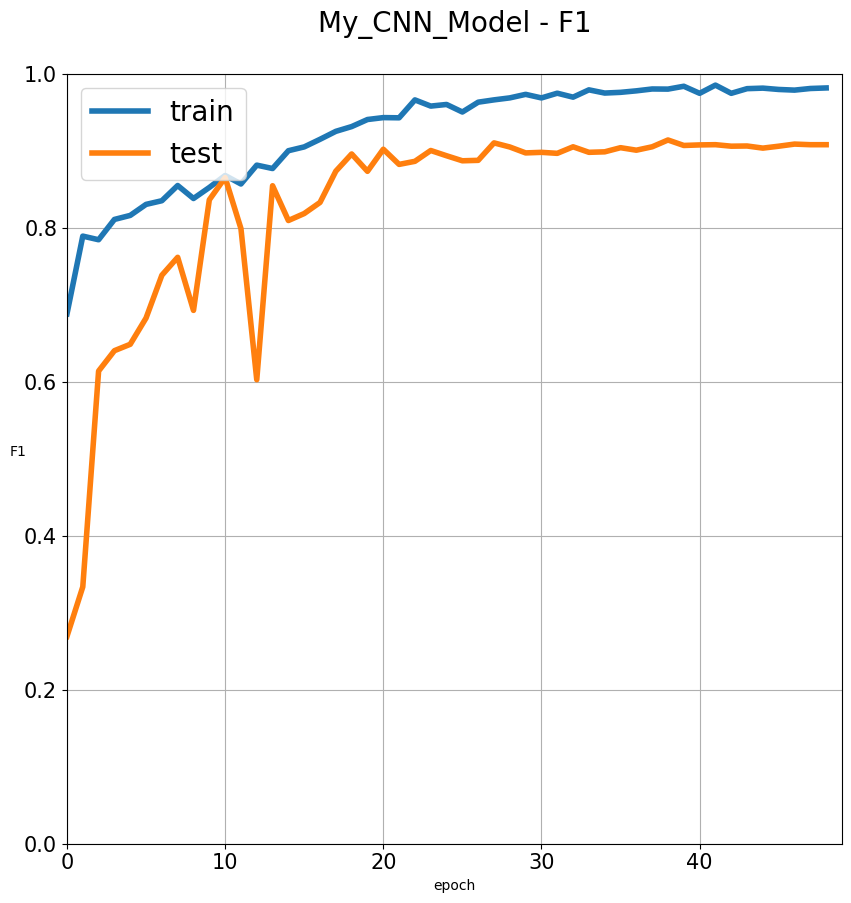

Final F1 for train: 0.982
Final F1 for test: 0.908


<Figure size 640x480 with 0 Axes>

In [ ]:
plot_f1_history("My_CNN_Model", history)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


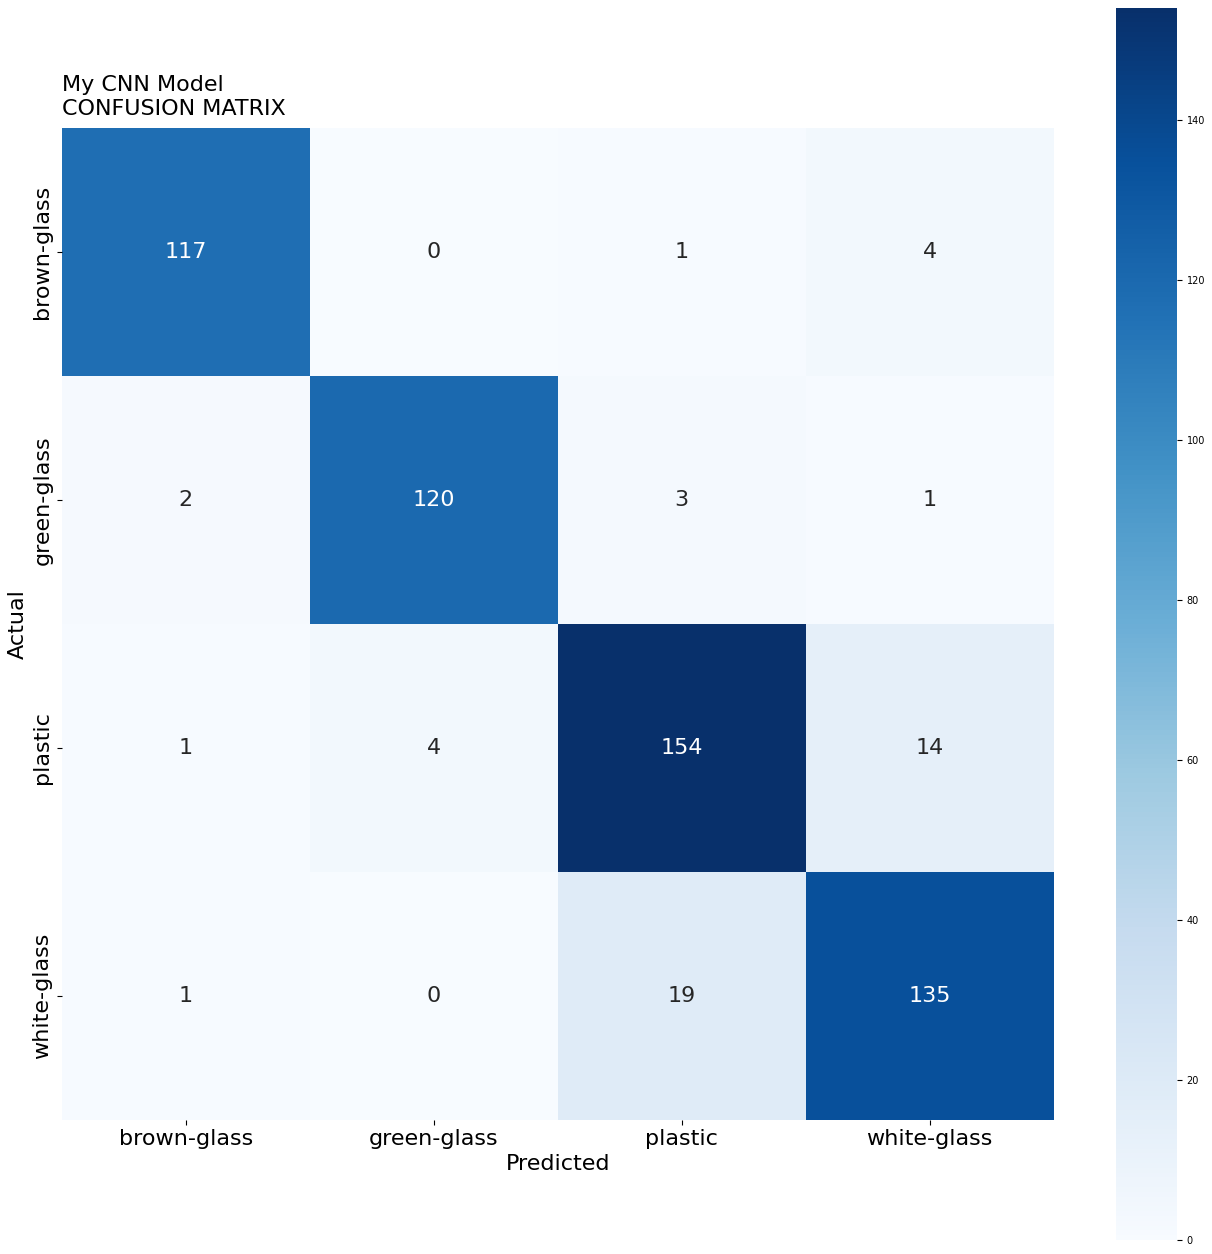

In [ ]:
predictions = model.predict(X_val_r)
model_y_pred = np.argmax(predictions, axis=1)

make_confusion_matrix("My CNN Model", y_val, model_y_pred)

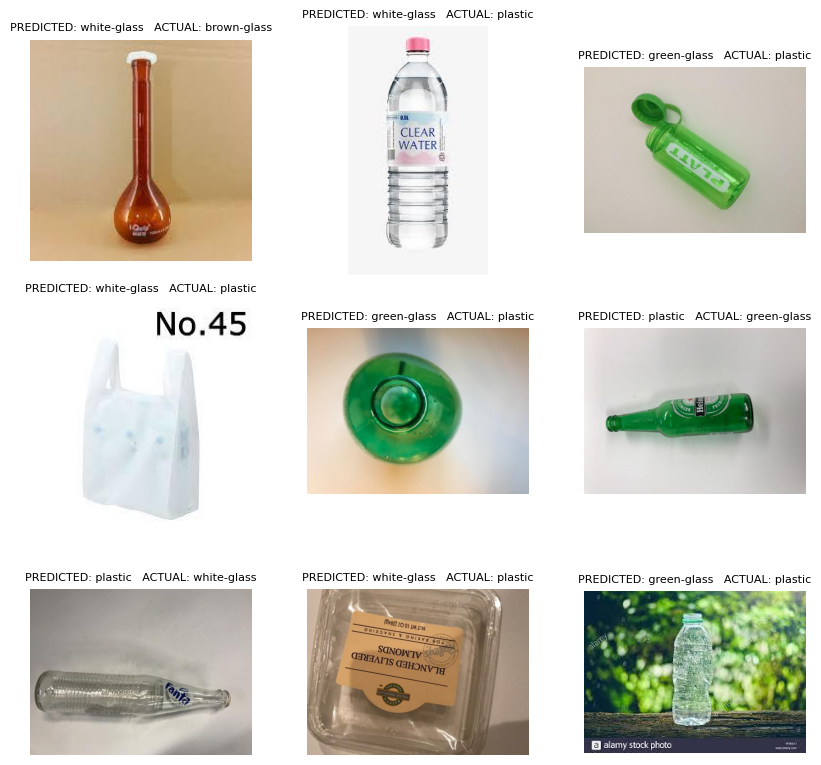

In [ ]:
show_misclassified(y_val, model_y_pred)

In [ ]:
# Evaluate the model on the validation set
loss, f1 = model.evaluate(X_val_r, y_val_cat, verbose=0)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_val, model_y_pred, target_names=label_to_name_dict.values()))

# Per-class F1 scores from the classification report
report_dict = classification_report(y_val, model_y_pred, target_names=label_to_name_dict.values(), output_dict=True)
print("\nPer-Class F1 Scores:")
for class_name, metrics in report_dict.items():
    if class_name in label_to_name_dict.values():
        print(f"{class_name}: {metrics['f1-score']:.4f}")


print(f"\nValidation Loss: {loss:.4f}")
print(f"Validation F1 Score: {f1:.4f}")
# Calculate overall accuracy
accuracy = accuracy_score(y_val, model_y_pred)
print(f"Overall Accuracy: {accuracy:.4f}")



Classification Report:
              precision    recall  f1-score   support

 brown-glass       0.97      0.96      0.96       122
 green-glass       0.97      0.95      0.96       126
     plastic       0.87      0.89      0.88       173
 white-glass       0.88      0.87      0.87       155

    accuracy                           0.91       576
   macro avg       0.92      0.92      0.92       576
weighted avg       0.91      0.91      0.91       576


Per-Class F1 Scores:
brown-glass: 0.9630
green-glass: 0.9600
plastic: 0.8800
white-glass: 0.8738

Validation Loss: 0.3344
Validation F1 Score: 0.9139
Overall Accuracy: 0.9132
